# Lecture 3.1 — Used Cars (Python version)
**Jackson School of Global Affairs**  
Reference: Békés & Kézdi (2021) https://gabors-data-analysis.com/

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from statsmodels.nonparametric.smoothers_lowess import lowess
import warnings
import os
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('usedcars_work.csv')
data.head()

,area,subarea,name,condition,cylinders,drive,fuel,odometer,paintcolor,size,...,LE,XLE,SE,cond_excellent,cond_good,cond_likenew,cylind6,agesq,agecu,odometersq
0,chicago,chicago city,2015 Toyota_ Camry_,excellent,other,Missing,gas,3.572100,NaN,NaN,...,0,0,0,1,0,0,0,9,27,12.759898
1,chicago,chicago city,2016 TOYOTA CAMRY,Missing,Missing,fwd,gas,1.315200,NaN,NaN,...,0,0,0,0,0,0,0,4,8,1.729751
2,chicago,chicago city,1993 toyota camry,good,6 cylinders,fwd,gas,18.700000,red,full-size,...,0,0,0,0,1,0,1,625,15625,349.690000
3,chicago,chicago city,1998 toyota camry le,Missing,Missing,Missing,gas,16.824259,NaN,NaN,...,1,0,0,0,0,0,0,400,8000,283.055684
4,chicago,chicago city,1998 Toyota Camry,Missing,Missing,Missing,gas,16.824259,NaN,NaN,...,0,0,0,0,0,0,0,400,8000,283.055684


## Model Formulas
Five candidate models of increasing complexity.

In [3]:
model1 = 'price ~ age + agesq'
model2 = 'price ~ age + agesq + odometer'
model3 = 'price ~ age + agesq + odometer + odometersq + LE + cond_excellent + cond_good + dealer'
model4 = 'price ~ age + agesq + odometer + odometersq + LE + XLE + SE + cond_likenew + cond_excellent + cond_good + cylind6 + dealer'
model5 = 'price ~ age + agesq + agecu + odometer + odometersq + LE:age + XLE:age + SE:age + cond_likenew:age + cond_excellent:age + cond_good:age + cylind6:age + odometer:age + dealer:age'

models = {
    'Model 1': model1,
    'Model 2': model2,
    'Model 3': model3,
    'Model 4': model4,
    'Model 5': model5,
}

## Task 1 — Scatterplot with LOWESS curve
Does the relationship between car age and price justify including age in the models?

Text(0.5, 1.0, 'Price by Age')

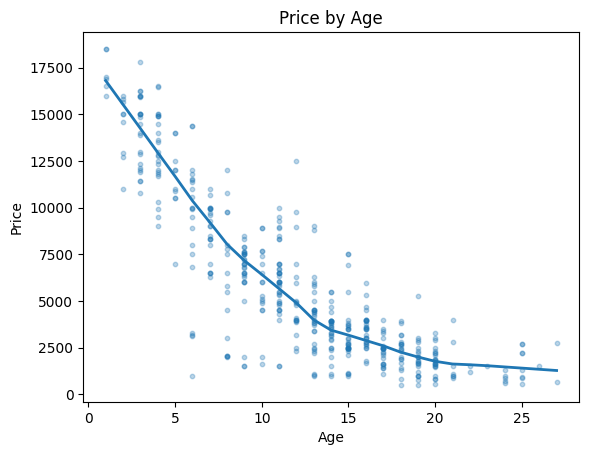

In [10]:
# Create the scatter plot and the lowess curve. 

lowess_fit = lowess(
    endog=data['price'],
    exog=data['age'],
    frac=0.3   # smoothing parameter 
) 

plt.scatter(data["age"], data["price"], alpha=0.3, s=10)
plt.plot(lowess_fit[:, 0], lowess_fit[:, 1], linewidth=2)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price by Age")

## Task 2 — Model Comparison: Adjusted R², AIC, BIC, RMSE
Fit all five models with heteroskedasticity-robust standard errors (HC3) and compare fit statistics.

In [11]:
results = {}
for name, formula in models.items():
    fit = smf.ols(formula, data=data).fit(cov_type='HC3')
    preds = fit.fittedvalues
    rmse  = root_mean_squared_error(data['price'], preds)
    results[name] = {
        'AIC':          round(fit.aic, 2),
        'BIC':          round(fit.bic, 2),
        'RMSE':         round(rmse, 2),
        'R²':           round(fit.rsquared, 4),
        'Adj. R²':      round(fit.rsquared_adj, 4),
        'N':            int(fit.nobs),
    }

summary_df = pd.DataFrame(results).T
print(summary_df.to_string())

             AIC      BIC     RMSE      R²  Adj. R²      N
Model 1  8560.90  8573.41  1862.54  0.8148   0.8140  478.0
Model 2  8442.54  8459.22  1642.22  0.8560   0.8551  478.0
Model 3  8372.21  8409.74  1509.86  0.8783   0.8762  478.0
Model 4  8374.64  8428.84  1501.09  0.8797   0.8766  478.0
Model 5  8397.67  8460.21  1531.27  0.8748   0.8710  478.0


## Task 3 — Cross-Validation (4-fold CV RMSE)
k-fold CV tells us how well each model generalises to unseen data.  
We split the data into 4 folds, train on 3, test on the held-out fold, and rotate.

In [16]:
# Make comments on what the CV line means. 

np.random.seed(13505)

k_folds = 4
kf = KFold(n_splits=k_folds, shuffle=True, random_state=13505)

def run_cv(formula, data, kf):
    """Run k-fold CV for a given statsmodels formula string.
    Returns a list of per-fold RMSE values."""
    fold_rmses = []
    for train_idx, test_idx in kf.split(data):
        train_data = data.iloc[train_idx]
        test_data  = data.iloc[test_idx]
        fit        = smf.ols(formula, data=train_data).fit()
        preds      = fit.predict(test_data)
        actual     = test_data['price']
        fold_rmses.append(root_mean_squared_error(actual, preds))
    return fold_rmses

cv_results = {name: run_cv(formula, data, kf) for name, formula in models.items()}

# Build summary table
cv_mat = pd.DataFrame(cv_results, index=[f'Fold {i+1}' for i in range(k_folds)])
cv_mat.loc['Average'] = cv_mat.mean()
print(cv_mat.round(2).to_string())

         Model 1  Model 2  Model 3  Model 4  Model 5
Fold 1   1795.79  1554.44  1430.65  1463.67  1466.86
Fold 2   1714.99  1444.10  1382.96  1385.40  1386.87
Fold 3   1969.49  1915.54  1795.26  1791.90  1863.08
Fold 4   1984.12  1683.71  1492.53  1563.68  1616.28
Average  1866.10  1649.45  1525.35  1551.16  1583.27


## Task 4 — Prediction with Point Estimate and Interval
Predict the price of a 10-year-old LE trim Toyota with excellent condition, 12k miles, no dealer, 4-cylinder engine.

In [13]:
new_car = pd.DataFrame([{
    'age':           10,
    'agesq':         10**2,
    'odometer':      12,
    'odometersq':    12**2,
    'SE':            0,
    'XLE':           0,
    'LE':            1,
    'cond_likenew':  0,
    'cond_excellent':1,
    'cond_good':     0,
    'dealer':        0,
    'cylind6':       0,
}])

model_chosen = smf.ols(model3, data=data).fit(cov_type='HC3')

# statsmodels get_prediction() returns point estimate + interval
pred95 = model_chosen.get_prediction(new_car).summary_frame(alpha=0.05)  

print('95% Prediction Interval:')
print(pred95[['mean', 'obs_ci_lower', 'obs_ci_upper']].round(2).to_string(index=False))

# Now create the 85% interval and show it. 


95% Prediction Interval:
   mean  obs_ci_lower  obs_ci_upper
5935.69       2926.85       8944.54
